<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Pro/HW2_Gradient_descent_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Домашнее задание: Градиентный спуск — продвинутая часть**

В этом домашнем задании вы ещё раз закрепите **градиентный спуск**, но уже в модифицированном виде.
Вы реализуете различные виды GD, закрепите на практике их свойства и улучшения и научитесь интерпретировать результаты.


**Дедлайн: 13 декабря 23:59**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.datasets import make_classification, make_regression
from sklearn.preprocessing import StandardScaler
import pandas as pd

np.random.seed(42)

### **Задание 1. Зоопарк оптимизаторов (5 баллов)**


Обычный градиентный спуск с постоянным шагом хорошо работает на простых выпуклых функциях, но резко теряет эффективность, как только ландшафт становится более сложным. В реальности ландшафт сложный всегда — если мы работаем с нейронной сетью — параметров много и функции сложные. В них есть разные проблемы (лучше, чем читать — посмотреть [здесь](https://losslandscape.com/gallery/)):

* узкие долины,
* сильно различающиеся масштабы по координатам,
* плоскости с почти нулевым градиентом,
* рябь, плоскости, седловые точки.

В таких ситуациях стандартный GD перестаёт справляться, поэтому в современной оптимизации почти никогда не используют голый вариант GD. Его заменяют **модифицированные методы**, которые:

* адаптируют шаг обучения под каждую координату,
* сглаживают траекторию накоплением информации о прошлых градиентах,
* корректируют скорость движения в зависимости от геометрии ландшафта.

В этом задании мы будем реализовывать такие методы в единой архитектуре.

#### **Задание 1.1 Реализация золотой пятерки (3 балла)**

Ниже в коде уже реализован общий базовый класс `Optimizer`, который:

* содержит цикл обучения (`fit`),
* считает градиенты,
* сохраняет историю оптимизации,
* контролирует количество итераций,
* передаёт параметры в оптимизатор.

Ваша задача, для каждого типа оптимизатора, реализовать метод:

```python
def step(self, params, gradient, iteration):
    ...
```

Он принимает, текущие параметры, текущий градиент, номер итерации и должен вернуть обновлённые параметры.


#### **Золотая пятерка**

0. **Vanilla Gradient Descent**
   $$w_{t+1} = w_t - \eta\nabla L(w_t)$$
   
   где $\eta$ — шаг обучения, $\nabla L(w_t)$ — градиент в точке $w_t$.

1. **Momentum (градиентный спуск с моментом)** —  накапливаем “скорость” (усреднённый градиент), чтобы сгладить траекторию и ускориться вдоль долины.
  $$v_t = \beta v_{t-1} + (1 - \beta)\nabla L(w_t)$$
  $$w_{t+1} = w_t - \eta v_t$$
   где $v_t$ — скорость, $\beta \in [0,1)$ — коэффициент затухания (часто 0.9).

2. **Nesterov Accelerated Gradient (NAG, ускоренный градиент Нестерова)** —  градиент вычисляется в точке, куда мы *ещё только собираемся сделать шаг*.

  $$v_t = \beta v_{t-1} + (1 - \beta) \nabla L(w_t)$$
  $$w_{t+1} = w_t - \eta \left( \beta v_t + (1 - \beta)\nabla L(w_t) \right)$$

3. **AdaGrad** — реализует адаптивный шаг обучения на основе накопления квадратов градиента. Идея такая — ксли по некоторой координате градиенты большие — по ней уменьшать шаг, а если градиенты маленькие → шаг остаётся большим.

$$G_t = G_{t-1} + (\nabla L(w_t))^2$$
$$\eta_t = \frac{\eta}{\sqrt{G_t+\varepsilon}}$$
$$w_{t+1} = w_t - \eta_t \nabla L(w_t)$$

где $\varepsilon$ — стабилизация — чтобы не делить на ноль.


4. **RMSprop** — экспоненциальное сглаживание квадратов градиента. Идея тут — убить недостаток AdaGrad —  онслишком быстро уменьшает шаг, поэтому RMSprop заменяет сумму экспоненциальным средним.

$$s_t = \beta s_{t-1} + (1 - \beta)(\nabla L(w_t))^2$$
$$\eta_t = \frac{\eta}{\sqrt{s_t + \varepsilon}}$$
$$w_{t+1} = w_t - \eta_t \nabla L(w_t)$$


5. **Adam** — Momentum + RMSprop одновременно. Идейно Adam поддерживает две экспоненциальные скользящие средние:

* $m_t$ — среднее градиентов (как momentum),
* $v_t$ — среднее квадратов градиентов (как RMSprop).

Кроме того, вводится коррекция смещения.

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1)\nabla L(w_t)$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2)(\nabla L(w_t))^2$$

$$\hat m_t = \frac{m_t}{1 - \beta_1^t}$$
$$\hat v_t = \frac{v_t}{1 - \beta_2^t}$$

$$w_{t+1} = w_t - \eta \frac{\hat m_t}{\sqrt{\hat v_t + \varepsilon}}$$



**Для каждого оптимизатора вы должны написать класс, наследуемый от `Optimizer`, и в нем метод `step()` ровно по формулам выше.
Без внешних библиотек, никаких упрощений. При этом:**


* Базовый класс `Optimizer` уже полностью готов, но в нем <font color="red">специально допущено несколько ошибок. Исправьте их.</font>
* Далее ваша задача — лишь реализовать формулы обновления весов в соответствующих классах.
* После реализации протестируйте оптимизаторы (это будет следующее задание).

In [2]:
class Optimizer:
    """Базовый класс для оптимизаторов"""

    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.history = {
            'params': [],
            'loss': [],
            'gradients': []
        }

    def step(self, params, gradient):
        """Один шаг оптимизации - должен быть переопределён"""
        raise NotImplementedError

    def fit(self, loss_fn, grad_fn, initial_params):
        params = initial_params.copy()

        for _ in range(self.n_iterations):
            gradient = grad_fn(params)

            self.history['params'].append(params.copy())
            self.history['loss'].append(loss_fn(params))
            self.history['gradients'].append(gradient.copy())

            params = self.step(params, gradient)

        self.history['params'].append(params.copy())
        self.history['loss'].append(loss_fn(params))
        self.history['gradients'].append(grad_fn(params))

        return params


class VanillaGD(Optimizer):
    """Обычный градиентный спуск"""

    def step(self, params, gradient):
        return params - self.learning_rate  * gradient


class MomentumGD(Optimizer):
    """GD с momentum"""

    def __init__(self, learning_rate=0.01, n_iterations=100, beta=0.9):
        super().__init__(learning_rate, n_iterations)
        self.beta = beta
        self.velocity = 0

    def step(self, params, gradient):
        self.velocity = self.beta * self.velocity + (1 - self.beta) * gradient
        return params - self.learning_rate * self.velocity

class NesterovGD(Optimizer):
    """Nesterov Accelerated Gradient"""

    def __init__(self, learning_rate=0.01, n_iterations=100, beta=0.9):
        super().__init__(learning_rate, n_iterations)
        self.beta = beta
        self.velocity = 0

    def step(self, params, gradient):
        self.velocity = self.beta * self.velocity + (1 - self.beta) * gradient
        return params - self.learning_rate * (self.beta * self.velocity + (1 - self.beta) * gradient)


class AdaGrad(Optimizer):
    """AdaGrad optimizer"""

    def __init__(self, learning_rate=0.01, n_iterations=100, epsilon=1e-8):
        super().__init__(learning_rate, n_iterations)
        self.epsilon = epsilon
        self.accumulated_grad = 0

    def step(self, params, gradient):
        self.accumulated_grad = self.accumulated_grad + np.power(gradient, 2)
        eta = self.learning_rate / np.sqrt(self.accumulated_grad + self.epsilon)
        return params - eta * gradient


class RMSprop(Optimizer):
    """RMSprop optimizer"""

    def __init__(self, learning_rate=0.01, n_iterations=100, beta=0.9, epsilon=1e-8):
        super().__init__(learning_rate, n_iterations)
        self.beta = beta
        self.epsilon = epsilon
        self.squared_grad = 0

    def step(self, params, gradient):
        self.squared_grad = self.beta * self.squared_grad + (1 - self.beta) * np.power(gradient, 2)
        eta = self.learning_rate / np.sqrt(self.squared_grad + self.epsilon)
        return params - eta * gradient


class Adam(Optimizer):
    """Adam optimizer"""

    def __init__(self, learning_rate=0.01, n_iterations=100, beta1=0.9, beta2=0.999, epsilon=1e-8):
        super().__init__(learning_rate, n_iterations)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = 0
        self.v = 0

    def step(self, params, gradient):
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradient
        self.v = self.beta2 * self.v + (1 - self.beta2) * np.power(gradient, 2)
        m_hat = self.m / (1 - self.beta1)
        v_hat = self.v / (1 - self.beta2)
        return params - self.learning_rate * m_hat / np.sqrt(v_hat + self.epsilon)


Поправил ошибки при добавлении данных в `self.history`. Также у всех имплементаций метода `step` удалил параметр `iteration`, т.к. его использование мне кажется избыточным. Для расчета шага номер итерации не обязателен - это излишнее усложнение. А далее в данных истории определить какой параметр какой итерации принадлежит возможно по её индексу в списке.

#### **Задание 1.2 Тестирование золотой пятерки (2 балла)**

Протестируем оптимизиторы на красивой двумерной функции — **функции Растригина (Rastrigin function)**. Почему именно она? На самом деле, существует несколько [популярных функций-тестов](https://en.wikipedia.org/wiki/Test_functions_for_optimization) для функций оптимизации. И все они безумно красивые. Просто эта — [особенно хорошо отражает сложные ландшафты](https://en.wikipedia.org/wiki/Rastrigin_function). Она имеет:

* большое число локальных экстремумов,
* регулярную рябь по всей области,
* хорошо выраженный глобальный минимум.

Её аналитическая форма в двумерном случае:

$$f(x, y) = 20 + x^2 + y^2 - 10(\cos(2\pi x) + \cos(2\pi y))$$

Глобальный минимум:

$$(x^*, y^*) = (0,0), \quad f(x^*, y^*) = 0.$$


**Что сделать в задании:**
1. Реализовать функцию (двумерную) и ее градиент

2. Запустить каждый оптимизатор:

   * записать функцию и её градиент;
   * запустить оптимизиторы из данной стартовой точки (она прописана в коде), с прописанным базовым learning rate.

3. Для каждого метода вывести:

   * итоговые значения аргументов $x$ и $y$,
   * финальное значение функции потерь.


4. Сделать краткий анализ. Можно опираться на вопросы:

   * Какие методы сходятся быстрее?
   * Кто застрял в локальных минимумах?
   * Насколько траектории “дрожат”?
   * Как адаптивные методы корректируют шаг?
   * Какие методы вышли ближе всего к глобальному минимуму?






In [3]:
def rastrigin_function(params, A=10.0):
    """
    Rastrigin function (2D).
    f(x, y) = 2A + x^2 - A cos(2πx) + y^2 - A cos(2πy)
    Глобальный минимум: (0, 0), f = 0.
    """
    # Реализовал расчет функции в векторном виде
    return 2 * A + np.sum(np.power(params, 2)) - A * np.sum(np.cos(2 * np.pi * params))

def rastrigin_gradient(params, A=10.0):
    """
    Gradient of Rastrigin function.
    ∂f/∂x = 2x + 2πA sin(2πx)
    ∂f/∂y = 2y + 2πA sin(2πy)
    """
    # Реализовал расчет градиента в векторном виде
    return 2 * params + 2 * np.pi * A * np.sin(2 * np.pi * params)

# Параметры
initial_point = np.array([-1.0, 2.0])  # стартовая точка вдали от минимума — не меняем!
n_iter = 300

# Создаём оптимизаторы
optimizers = {
    'GD':       VanillaGD(learning_rate=0.05, n_iterations=n_iter),
    'Momentum': MomentumGD(learning_rate=0.05, n_iterations=n_iter, beta=0.9),
    'NAG':      NesterovGD(learning_rate=0.05, n_iterations=n_iter, beta=0.9),
    'AdaGrad':  AdaGrad(learning_rate=0.05,  n_iterations=n_iter),
    'RMSprop':  RMSprop(learning_rate=0.05,  n_iterations=n_iter, beta=0.9),
    'Adam':     Adam(learning_rate=0.05,     n_iterations=n_iter)
}

# Создаём сетку для визуализации
x_range = np.linspace(-5.5, 5.5, 300)
y_range = np.linspace(-5.5, 5.5, 300)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)

for i in range(len(x_range)):
    for j in range(len(y_range)):
        Z[j, i] = rastrigin_function(np.array([X[j, i], Y[j, i]]))

# Обучаем все оптимизаторы
results = {}
for name, optimizer in optimizers.items():
    final_params = optimizer.fit(rastrigin_function, rastrigin_gradient, initial_point)
    results[name] = optimizer.history
    print(f"{name:12s}: Final loss = {rastrigin_function(final_params):.6f}, "
          f"Params = [{final_params[0]:.4f}, {final_params[1]:.4f}]")

print("\nГлобальный минимум (True): [0, 0]")

# Визуализация траекторий — если вы ничего не меняли в базовом классе — оно просто запустится
fig_opt = go.Figure()

# Контур функции
fig_opt.add_trace(
    go.Contour(
        x=x_range,
        y=y_range,
        z=np.log10(Z + 1),  # лог по (f + 1), чтобы избежать log(0)
        colorscale='Viridis',
        showscale=False,
        contours=dict(start=0, end=3, size=0.1),
        opacity=0.6,
        name='Rastrigin function (log scale)'
    )
)

# Траектории всех оптимизаторов
colors = ['red', 'blue', 'green', 'orange', 'purple', 'pink']
for idx, (name, history) in enumerate(results.items()):
    trajectory = np.array(history['params'])
    fig_opt.add_trace(
        go.Scatter(
            x=trajectory[:, 0],
            y=trajectory[:, 1],
            mode='lines',
            line=dict(color=colors[idx], width=2),
            name=name
        )
    )

# Глобальный минимум
fig_opt.add_trace(
    go.Scatter(
        x=[0.0], y=[0.0],
        mode='markers',
        marker=dict(size=15, color='yellow', symbol='star',
                    line=dict(color='black', width=2)),
        name='Глобальный минимум'
    )
)

# Стартовая точка
fig_opt.add_trace(
    go.Scatter(
        x=[initial_point[0]], y=[initial_point[1]],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x'),
        name='Старт'
    )
)

fig_opt.update_layout(
    title="Сравнение оптимизаторов на Rastrigin function",
    xaxis_title="x",
    yaxis_title="y",
    hovermode='closest',
    width=900,
    height=700
)

fig_opt.show()


GD          : Final loss = 86.423278, Params = [-6.4574, 4.9420]
Momentum    : Final loss = 4.974790, Params = [-0.9950, 1.9899]
NAG         : Final loss = 17.908477, Params = [-1.1932, 2.1714]
AdaGrad     : Final loss = 4.974790, Params = [-0.9950, 1.9899]
RMSprop     : Final loss = 5.220721, Params = [-1.0199, 2.0148]
Adam        : Final loss = 4.974790, Params = [-0.9950, 1.9899]

Глобальный минимум (True): [0, 0]


**Ваш анализ здесь**
1. Чего не хватило адаптивным методам? Что с ними произошло?  
Все адаптивные методы не смогли выбраться из локального минимума и застряли в нем. Но каждый из них показал различное поведение. Быстрее всех сошлись `Momentum`, `AdaGrad`, `Adam`. Причем все три сошлись в одной точке $(-0.9950, 1.9899)$. По графику похоже, что они нашли именно локальный минимум (практически в точке старта).  
`NAG` и `RMSprop` сходились дольше и судя по всему не дошли до локального минимума.  
Траектория`Momentum` самая простая - он отступал от изначальной точки всего в одну сторону, но быстро вернулся обратно.  
`GD`, в отличии от адаптивных методов, вышел из локального минимума, но его траектория представляет собой стохастическое блуждание по всему графку. В итоге он остановился в точке, далектой от локального минимума. Также, несмотря на то, что он смог "прогуляться" по графику, найденая точка, судя по лоссу, сильно хуже локального минимума, в котором застряли адаптивные методы.  
Из адаптивных методов у `NAG` наблюдается наибольшая дисперсия шагов оптимизатора. Но в общем, все они "скакали" в основном в 2-х направлениях от изначальной точки с небольшими вариациями от метода к методу. Думаю, что такое поведение связано со строением поверхности, описываемой функцией Растригина.  
2. Почему градиетному спуску так плохо?
Выражаясь терминами из повседневной жизни, из-за сложного "рельефа" функции градиентный спуск "запутался" в локальных экстремумах и "сбился с пути". Т.е. из-за зафиксированного `learning rate` его шага хватало выбираться из локальных минимумов, но он не смог остановиться около глобального минимума и пошел дальше. Хотя, судя по графику, он проходил рядом с ним.

### **Задание 2. Анализ Losses (2 балла)**



В реализации базового класса `Optimizer`, при каждом спуске сохраняются графики loss-функции. Их в процессе обучения мы также анализируем. Напомним, что говорят, что **loss “сходится”**, если выполняются следующие признаки:

1. Значение loss $L(w_k)$ монотонно убывает и приближается к некоторому предельному значению (выходит на плато):
   $$|L(w_{k+1}) - L(w_k)| \to 0$$

Сошелся ли лосс у нас? Используйте ваши реализации из заданий 1–2:

1. Постройте графики значения loss, проанализируйте, какие спуски сошлись.
2. Поизменяйте learning rate, обучите спуски ещё и снова выведите лосс. Как learning rate влияет на результат и удалось ли сойтись теперь?

In [4]:
# Подготавливаю датафрейм с лоссами для их визуализации
dfs_list = []
for opt_name in results.keys():
    dfs_list.append(
        pd.DataFrame(data=results[opt_name]['loss'], columns=['loss'])
        .assign(optimizer=opt_name)
        .reset_index()
        .rename(columns={'index': 'iter_num'})
    )

df_to_plot = pd.concat(dfs_list, ignore_index=True)
df_to_plot

# Строю график
fig = px.line(data_frame=df_to_plot, x='iter_num', y='loss', color='optimizer', title="Optimizers loss")
fig.show()

Вначале у всех отпимизаторов наблюдаются сильные колебания лосса. Но у `Adam`, `AdaGrad`, `Momentum` лосс после 30 итерации становился стабильнее, а после 50-й - монотонный. Наименьшая дисперсия ошибки на начальных итерациях обучения наблюдается у `Momentum`. А у `AdaGrad` на 1-й итерации есть скачек лосса вверх, но со второй итерации он выравнивается. 

In [5]:
def test_whole_optimizers(learning_rate):
    # Параметры
    initial_point = np.array([-1.0, 2.0])  # стартовая точка вдали от минимума — не меняем!
    n_iter = 300

    # Создаём оптимизаторы
    optimizers = {
        'GD':       VanillaGD(learning_rate=learning_rate,  n_iterations=n_iter),
        'Momentum': MomentumGD(learning_rate=learning_rate, n_iterations=n_iter, beta=0.9),
        'NAG':      NesterovGD(learning_rate=learning_rate, n_iterations=n_iter, beta=0.9),
        'AdaGrad':  AdaGrad(learning_rate=learning_rate,    n_iterations=n_iter),
        'RMSprop':  RMSprop(learning_rate=learning_rate,    n_iterations=n_iter, beta=0.9),
        'Adam':     Adam(learning_rate=learning_rate,       n_iterations=n_iter)
    }

    # Обучаем все оптимизаторы
    results = {}
    for name, optimizer in optimizers.items():
        final_params = optimizer.fit(rastrigin_function, rastrigin_gradient, initial_point)
        results[name] = optimizer.history
        print(f"{name:12s}, learning_rate={learning_rate}: Final loss = {rastrigin_function(final_params):.6f}, "
            f"Params = [{final_params[0]:.4f}, {final_params[1]:.4f}]")
    
    # Подготавливаю датафрейм с лоссами для их визуализации
    dfs_list = []
    for opt_name in results.keys():
        dfs_list.append(
            pd.DataFrame(data=results[opt_name]['loss'], columns=['loss'])
            .assign(optimizer=opt_name)
            .reset_index()
            .rename(columns={'index': 'iter_num'})
        )

    df_to_plot = pd.concat(dfs_list, ignore_index=True)
    df_to_plot

    # Строю график
    fig = px.line(data_frame=df_to_plot, x='iter_num', y='loss', color='optimizer', title=f"Optimizers loss with learninig rate={lr}")
    fig.show()

In [14]:
for lr in [0.01, 0.05, 0.1, 0.5]:
  test_whole_optimizers(learning_rate=lr)

GD          , learning_rate=0.01: Final loss = 32.481331, Params = [-0.7525, 2.3624]
Momentum    , learning_rate=0.01: Final loss = 4.974790, Params = [-0.9950, 1.9899]
NAG         , learning_rate=0.01: Final loss = 4.974790, Params = [-0.9950, 1.9899]
AdaGrad     , learning_rate=0.01: Final loss = 4.974790, Params = [-0.9950, 1.9899]
RMSprop     , learning_rate=0.01: Final loss = 4.984687, Params = [-1.0000, 1.9949]
Adam        , learning_rate=0.01: Final loss = 4.974790, Params = [-0.9950, 1.9899]


GD          , learning_rate=0.05: Final loss = 86.423278, Params = [-6.4574, 4.9420]
Momentum    , learning_rate=0.05: Final loss = 4.974790, Params = [-0.9950, 1.9899]
NAG         , learning_rate=0.05: Final loss = 17.908477, Params = [-1.1932, 2.1714]
AdaGrad     , learning_rate=0.05: Final loss = 4.974790, Params = [-0.9950, 1.9899]
RMSprop     , learning_rate=0.05: Final loss = 5.220721, Params = [-1.0199, 2.0148]
Adam        , learning_rate=0.05: Final loss = 4.974790, Params = [-0.9950, 1.9899]


GD          , learning_rate=0.1: Final loss = 127.970191, Params = [-9.9710, -4.2545]
Momentum    , learning_rate=0.1: Final loss = 7.378101, Params = [-1.0745, 2.0670]
NAG         , learning_rate=0.1: Final loss = 108.212896, Params = [4.0223, -8.6055]
AdaGrad     , learning_rate=0.1: Final loss = 4.974790, Params = [-0.9950, 1.9899]
RMSprop     , learning_rate=0.1: Final loss = 5.947148, Params = [-1.0447, 2.0394]
Adam        , learning_rate=0.1: Final loss = 4.974790, Params = [-0.9950, 1.9899]


GD          , learning_rate=0.5: Final loss = 990.961637, Params = [31.2509, 0.8617]
Momentum    , learning_rate=0.5: Final loss = 648.431405, Params = [10.6028, -22.3786]
NAG         , learning_rate=0.5: Final loss = 245.508076, Params = [-1.5873, 14.8594]
AdaGrad     , learning_rate=0.5: Final loss = 0.994959, Params = [-0.0000, 0.9950]
RMSprop     , learning_rate=0.5: Final loss = 38.464845, Params = [2.3068, 0.4469]
Adam        , learning_rate=0.5: Final loss = 0.994959, Params = [0.0000, 0.9950]


**Как learning rate влияет на результат и удалось ли сойтись теперь?**  
С увличением значения learning rate, лосс у `GD` заметно вырос. `Momentum`, `NAG`, `RMSprop` также стали более шумными и их итоговый лосс заметно увеличился. А вот loss у `AdaGrad` и `Adam` на первых итерация также стал выше (по всей видимости, чтобы выбраться из локального минимума, в котором они застревали), а потом выровнялся и итоговый лосс стал примерно в 5 раз меньше, чем  изначально. Такого результата удалось добиться при learning_rate=0.5.  
Обучу оптимизаторы с этим learning_rate и визуализирую их траектории. 

In [ ]:
# Параметры
initial_point = np.array([-1.0, 2.0])  # стартовая точка вдали от минимума — не меняем!
n_iter = 300

# Создаём оптимизаторы
optimizers = {
    'GD':       VanillaGD(learning_rate=0.5, n_iterations=n_iter),
    'Momentum': MomentumGD(learning_rate=0.5, n_iterations=n_iter, beta=0.9),
    'NAG':      NesterovGD(learning_rate=0.5, n_iterations=n_iter, beta=0.9),
    'AdaGrad':  AdaGrad(learning_rate=0.5,  n_iterations=n_iter),
    'RMSprop':  RMSprop(learning_rate=0.5,  n_iterations=n_iter, beta=0.9),
    'Adam':     Adam(learning_rate=0.5,     n_iterations=n_iter)
}

# Создаём сетку для визуализации
x_range = np.linspace(-5.5, 5.5, 300)
y_range = np.linspace(-5.5, 5.5, 300)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)

for i in range(len(x_range)):
    for j in range(len(y_range)):
        Z[j, i] = rastrigin_function(np.array([X[j, i], Y[j, i]]))

# Обучаем все оптимизаторы
results = {}
for name, optimizer in optimizers.items():
    final_params = optimizer.fit(rastrigin_function, rastrigin_gradient, initial_point)
    results[name] = optimizer.history
    print(f"{name:12s}: Final loss = {rastrigin_function(final_params):.6f}, "
          f"Params = [{final_params[0]:.4f}, {final_params[1]:.4f}]")

print("\nГлобальный минимум (True): [0, 0]")

# Визуализация траекторий — если вы ничего не меняли в базовом классе — оно просто запустится
fig_opt = go.Figure()

# Контур функции
fig_opt.add_trace(
    go.Contour(
        x=x_range,
        y=y_range,
        z=np.log10(Z + 1),  # лог по (f + 1), чтобы избежать log(0)
        colorscale='Viridis',
        showscale=False,
        contours=dict(start=0, end=3, size=0.1),
        opacity=0.6,
        name='Rastrigin function (log scale)'
    )
)

# Траектории всех оптимизаторов
colors = ['red', 'blue', 'green', 'orange', 'purple', 'pink']
for idx, (name, history) in enumerate(results.items()):
    trajectory = np.array(history['params'])
    fig_opt.add_trace(
        go.Scatter(
            x=trajectory[:, 0],
            y=trajectory[:, 1],
            mode='lines',
            line=dict(color=colors[idx], width=2),
            name=name
        )
    )

# Глобальный минимум
fig_opt.add_trace(
    go.Scatter(
        x=[0.0], y=[0.0],
        mode='markers',
        marker=dict(size=15, color='yellow', symbol='star',
                    line=dict(color='black', width=2)),
        name='Глобальный минимум'
    )
)

# Стартовая точка
fig_opt.add_trace(
    go.Scatter(
        x=[initial_point[0]], y=[initial_point[1]],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x'),
        name='Старт'
    )
)

fig_opt.update_layout(
    title="Сравнение оптимизаторов на Rastrigin function",
    xaxis_title="x",
    yaxis_title="y",
    hovermode='closest',
    width=900,
    height=700
)

fig_opt.show()


GD          : Final loss = 990.961637, Params = [31.2509, 0.8617]
Momentum    : Final loss = 648.431405, Params = [10.6028, -22.3786]
NAG         : Final loss = 245.508076, Params = [-1.5873, 14.8594]
AdaGrad     : Final loss = 0.994959, Params = [-0.0000, 0.9950]
RMSprop     : Final loss = 38.464845, Params = [2.3068, 0.4469]
Adam        : Final loss = 0.994959, Params = [0.0000, 0.9950]

Глобальный минимум (True): [0, 0]


Судя по визуализациям, `AdaGrad` и `Adam`не достигли глобального минимума, но подобрались к нему намного ближе, по сзавнению с прошлым разом.

### **Задание 3. Будь выпуклым (3 балла)**



На протяжении курса вы могли заметить, что мы всегда предпочитаем выпуклые функции потерь. Но насколько это требование жесткое? Давайте рассмотрим простейшую логистическую регрессию.

Модель:

$$p(x; w) = \sigma(z) = \sigma(w^\top x), \quad \sigma(z) = \frac{1}{1 + e^{-z}}.$$

Стандартный log-loss для одного объекта:

$$L_{\log}(p, y) = -\big( y \log p + (1-y)\log(1-p)\big), \quad y \in {0, 1}.$$

Рассмотрим для неё модифицированный loss — без логарифма. Просто опустим его, оставив линейную комбинацию вероятностей.

$$L_{\text{no-log}}(p, y) = -\big( y p + (1-y)(1-p)\big)$$


#### **3. 1. Логарифм? (2 балла)**

Попробуем понять, зачем вообще нам нужен логарифм.

1. Выведите производную logloss'a  без логарифма по $p$ **(только по $p$, по $w$ не надо!)**. Что получилось? Подумайте (погуглите), почему на практике используют логарифм.

2. Сравните качество:

   * обучите логистическую регрессию с обычным log-loss,
   * обучите с модифицированным loss без log,
   * сравните качество моделей. Поясните результаты.

  **В функциях градиенты должны быть уже по W**


Если брать производную logloss'а без логарифма, то получится $L'_{\text{no-log}}(p, y) = 1 - 2y$, т.к. $y \in {0, 1}$, т.е. константа, принимающая одно из двух значений, то и производная может принимать также всего 2 значения. Тут нечего оптимизировать. Поэтому и добавляют логарифмы в формулу.

In [8]:
# Генерация данных
X_class, y_class = make_classification(
    n_samples=1000,
    n_features=30,
    n_informative=20,
    random_state=42
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_class)
X_with_bias = np.column_stack([np.ones(len(X_scaled)), X_scaled])  # добавляем bias-столбец


# Функции для лосса
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Стандартный логистический log-loss
def logistic_loss(weights, X, y):
    """
    L_log(w) = - mean( y log p + (1-y) log(1-p) ),  p = sigmoid(X w)
    """
    p = sigmoid(X @ weights)
    return - np.mean(y @ np.log(p) + (1 - y) @ (np.log(1 - p)))


def logistic_gradient(weights, X, y):
    """
    grad_w L_log(w) = X^T (p - y) / N,  где p = sigmoid(X w)
    """
    p = sigmoid(X @ weights)
    return X.T @ (p - y) / len(y)

def without_log_loss(weights, X, y):
    """
    Log-loss без логарифма"
        L_no_log(w) = - mean( y p + (1 - y)(1 - p) ), p = sigmoid(X w)
    """
    p = sigmoid(X @ weights)
    return - np.mean(y @ p + (1 - y) @ (1 - p))


def without_log_loss_grad(weights, X, y):
    """
    Градиент L_no_log по w:
        dL/dp = 1 - 2y
        dp/dz = p (1-p)
        z = X w

    grad_w L_no_log = X^T * [ (1 - 2y) * p (1-p) ] / N
    """
    p = sigmoid(X @ weights)
    return X.T @ ((1 - 2 * y) * (p @ (1 - p))) / len(y)    

Проверим результаты.

* далее везде используйте окласс оптимизатора (`VanillaGD`) и одинаковую инициализацию весов;
* для каждой модели реализуйте свои `loss_fn` и `grad_fn` и передайте их в `fit` через `lambda`:

  ```python
  gd_log = VanillaGD(...)
  w_log = gd_log.fit(
      loss_fn=lambda w: logistic_loss(w, X_with_bias, y),
      grad_fn=lambda w: logistic_gradient(w, X_with_bias, y),
      initial_params=initial_weights
  )
  ```

  и аналогично для `no_log_loss` / `no_log_loss_grad`. Так всё заработает.


In [9]:
initial_weights = np.ones(X_with_bias.shape[1])

# Логистическая регрессия с log-loss
gd_log = VanillaGD(learning_rate=0.5, n_iterations=200)
w_log = gd_log.fit(
    loss_fn=lambda w: logistic_loss(w, X_with_bias, y_class),
    grad_fn=lambda w: logistic_gradient(w, X_with_bias, y_class),
    initial_params=initial_weights
)

# Логистическая регрессия с no-log loss
gd_no = VanillaGD(learning_rate=0.5, n_iterations=200)
w_no = gd_no.fit(
    loss_fn=lambda w: without_log_loss(w, X_with_bias, y_class),
    grad_fn=lambda w: without_log_loss_grad(w, X_with_bias, y_class),
    initial_params=initial_weights
)

def accuracy(weights):
    p = sigmoid(X_with_bias @ weights)
    y_pred = (p >= 0.5).astype(int)
    return (y_pred == y_class).mean()

print("\n=== Итоговые результаты (VanillaGD) ===")
print(f"log-loss:    final_loss = {logistic_loss(w_log, X_with_bias, y_class):.4f}, "
      f"accuracy = {accuracy(w_log):.4f}")
print(f"no-log loss: final_loss = {without_log_loss(w_no, X_with_bias, y_class):.4f}, "
      f"accuracy = {accuracy(w_no):.4f}")



=== Итоговые результаты (VanillaGD) ===
log-loss:    final_loss = 397.5690, accuracy = 0.8110
no-log loss: final_loss = -774.9022, accuracy = 0.7750


/tmp/ipykernel_707869/1725884872.py:16: RuntimeWarning:

overflow encountered in exp



In [10]:
# Подготавливаю датафрейм с лоссами
df_to_plot_2 = pd.concat([
    pd.DataFrame(data=gd_log.history['loss'], columns=['loss']).assign(optimizer='GD_log').reset_index().rename(columns={'index': 'iter_num'}),
    pd.DataFrame(data=gd_no.history['loss'], columns=['loss']).assign(optimizer='GD_wo_log').reset_index().rename(columns={'index': 'iter_num'})
], ignore_index=True)

# Строю график
fig = px.line(data_frame=df_to_plot_2, x='iter_num', y='loss', color='optimizer', title="Optimizers loss")
fig.show()

По графику хорошо видно, что с логарифмом в лосс-функции градиентный спуск сходится - идет плавное мнижение лосса. пока он не выходит на плато в районе 397-398.  
Без логарифма на первой итерации идет один скачек лосса вниз (причем находясь в области отрицательных значений по сути лосс становится еще хуже) и потом он уже не меняется на всём протяжении обучения. Как я писал выше, это связано с тем, что без логарифма модели нечего оптимизировать, т.к. значения logloss в этом случае - это константа.

#### **3. 2. И снова анализ (1 балл)**

Подумайте над результатами задания.
- Почему no-log выдал меньший loss? Значит ли это, что мы можем его использовать?
- Что будет, если подобрать гиперпараметр скорости спуска и попробовать другие оптимизаторы?

Реализуйте ваши эксперименты. За каждый — 0.5 балла (суммарно максимум 1 балл).

**Почему no-log выдал меньший loss? Значит ли это, что мы можем его использовать?**  
Могу только предположить, что это связано с тем, что при логарифмировании сигмоиды область ее значений получается в диапазоне от $(-\infty, 0)$. В формуле лосса вначале стоил знак минус. Поэтому в логарифмом лосс получается всегда положительным. А вот без логарифмирования, сигмоида лежит в диапазоне $(0, 1)$, а значил ее лосс получается отрицательным.  
Использовать его нельзя, т.к. с ним градиентный спуск не сходится. И вообще, то что его значения получились отрицательными - повод насторожиться, что такой лосс не применим для использования при обучении моделей.

In [11]:
def test_whole_optimizers_2(learning_rate):
    # Параметры
    initial_weights = np.ones(X_with_bias.shape[1])
    n_iter = 200

    # С логарифмом
    # Создаём оптимизаторы
    optimizers_log = {
        'GD':       VanillaGD(learning_rate=learning_rate,  n_iterations=n_iter),
        'Momentum': MomentumGD(learning_rate=learning_rate, n_iterations=n_iter, beta=0.9),
        'NAG':      NesterovGD(learning_rate=learning_rate, n_iterations=n_iter, beta=0.9),
        'AdaGrad':  AdaGrad(learning_rate=learning_rate,    n_iterations=n_iter),
        'RMSprop':  RMSprop(learning_rate=learning_rate,    n_iterations=n_iter, beta=0.9),
        'Adam':     Adam(learning_rate=learning_rate,       n_iterations=n_iter)
    }

    # Обучаем все оптимизаторы
    results_log = {}
    for name, optimizer in optimizers_log.items():
        final_params = optimizer.fit(
            loss_fn=lambda w: logistic_loss(w, X_with_bias, y_class),
            grad_fn=lambda w: logistic_gradient(w, X_with_bias, y_class),
            initial_params=initial_weights)
        results_log[name] = optimizer.history
        print(f"{name:12s}, learning_rate={learning_rate}: Final loss = {logistic_loss(final_params, X_with_bias, y_class):.6f}, "
            f"Params = [{final_params[0]:.4f}, {final_params[1]:.4f}]")
    
    # Подготавливаю датафрейм с лоссами для их визуализации
    dfs_list_log = []
    for opt_name in results_log.keys():
        dfs_list_log.append(
            pd.DataFrame(data=results_log[opt_name]['loss'], columns=['loss'])
            .assign(optimizer=opt_name)
            .reset_index()
            .rename(columns={'index': 'iter_num'})
        )

    df_to_plot_log = pd.concat(dfs_list_log, ignore_index=True)
    df_to_plot_log

    # Строю график
    fig = px.line(data_frame=df_to_plot_log, x='iter_num', y='loss', color='optimizer', title=f"Optimizers loss (with log) with learninig rate={lr}")
    fig.show()


     # Без логарифма
    # Создаём оптимизаторы
    optimizers_wo_log = {
        'GD':       VanillaGD(learning_rate=learning_rate,  n_iterations=n_iter),
        'Momentum': MomentumGD(learning_rate=learning_rate, n_iterations=n_iter, beta=0.9),
        'NAG':      NesterovGD(learning_rate=learning_rate, n_iterations=n_iter, beta=0.9),
        'AdaGrad':  AdaGrad(learning_rate=learning_rate,    n_iterations=n_iter),
        'RMSprop':  RMSprop(learning_rate=learning_rate,    n_iterations=n_iter, beta=0.9),
        'Adam':     Adam(learning_rate=learning_rate,       n_iterations=n_iter)
    }

    # Обучаем все оптимизаторы
    results_wo_log = {}
    for name, optimizer in optimizers_wo_log.items():
        final_params = optimizer.fit(
            loss_fn=lambda w: without_log_loss(w, X_with_bias, y_class),
            grad_fn=lambda w: without_log_loss_grad(w, X_with_bias, y_class),
            initial_params=initial_weights)
        results_wo_log[name] = optimizer.history
        print(f"{name:12s}, learning_rate={learning_rate}: Final loss = {without_log_loss(final_params, X_with_bias, y_class):.6f}, "
            f"Params = [{final_params[0]:.4f}, {final_params[1]:.4f}]")
    
    # Подготавливаю датафрейм с лоссами для их визуализации
    dfs_list_wo_log = []
    for opt_name in results_wo_log.keys():
        dfs_list_wo_log.append(
            pd.DataFrame(data=results_wo_log[opt_name]['loss'], columns=['loss'])
            .assign(optimizer=opt_name)
            .reset_index()
            .rename(columns={'index': 'iter_num'})
        )

    df_to_plot_wo_log = pd.concat(dfs_list_wo_log, ignore_index=True)
    df_to_plot_wo_log

    # Строю график
    fig = px.line(data_frame=df_to_plot_wo_log, x='iter_num', y='loss', color='optimizer', title=f"Optimizers loss (without log) with learninig rate={lr}")
    fig.show()

In [13]:
for lr in [0.01, 0.05, 0.1, 0.5]:
  test_whole_optimizers_2(learning_rate=lr)

GD          , learning_rate=0.01: Final loss = 1455.184703, Params = [0.9051, 0.8964]
Momentum    , learning_rate=0.01: Final loss = 1468.340555, Params = [0.9087, 0.9013]
NAG         , learning_rate=0.01: Final loss = 1467.016363, Params = [0.9084, 0.9008]
AdaGrad     , learning_rate=0.01: Final loss = 1312.539667, Params = [0.7471, 0.7353]
RMSprop     , learning_rate=0.01: Final loss = 398.860328, Params = [0.1308, -0.0196]
Adam        , learning_rate=0.01: Final loss = 407.215391, Params = [0.1257, -0.0160]


GD          , learning_rate=0.01: Final loss = -764.144136, Params = [1.1936, 0.7549]
Momentum    , learning_rate=0.01: Final loss = -764.459178, Params = [1.1992, 0.7478]
NAG         , learning_rate=0.01: Final loss = -764.416641, Params = [1.1984, 0.7488]
AdaGrad     , learning_rate=0.01: Final loss = -622.556811, Params = [1.2614, 0.7386]
RMSprop     , learning_rate=0.01: Final loss = -682.797053, Params = [2.9885, -0.9885]
Adam        , learning_rate=0.01: Final loss = -681.440905, Params = [2.8204, -0.8204]


GD          , learning_rate=0.05: Final loss = 694.109961, Params = [0.6222, 0.4968]
Momentum    , learning_rate=0.05: Final loss = 706.211556, Params = [0.6308, 0.5140]
NAG         , learning_rate=0.05: Final loss = 704.966943, Params = [0.6300, 0.5122]
AdaGrad     , learning_rate=0.05: Final loss = 469.367322, Params = [0.1711, 0.0578]
RMSprop     , learning_rate=0.05: Final loss = 399.420181, Params = [0.1665, -0.0536]
Adam        , learning_rate=0.05: Final loss = 397.537626, Params = [0.1440, -0.0275]


GD          , learning_rate=0.05: Final loss = -772.360031, Params = [1.5044, 0.3614]
Momentum    , learning_rate=0.05: Final loss = -772.524345, Params = [1.5267, 0.3331]
NAG         , learning_rate=0.05: Final loss = -772.495290, Params = [1.5227, 0.3381]
AdaGrad     , learning_rate=0.05: Final loss = -673.084420, Params = [2.1426, -0.1426]
RMSprop     , learning_rate=0.05: Final loss = -696.765038, Params = [10.1729, -8.1729]
Adam        , learning_rate=0.05: Final loss = -696.656116, Params = [7.3499, -5.3499]


GD          , learning_rate=0.1: Final loss = 471.440106, Params = [0.4155, 0.1820]
Momentum    , learning_rate=0.1: Final loss = 475.248478, Params = [0.4249, 0.1866]
NAG         , learning_rate=0.1: Final loss = 474.819270, Params = [0.4239, 0.1861]
AdaGrad     , learning_rate=0.1: Final loss = 402.994437, Params = [0.1231, -0.0197]
RMSprop     , learning_rate=0.1: Final loss = 411.339851, Params = [0.1540, -0.0040]
Adam        , learning_rate=0.1: Final loss = 397.537626, Params = [0.1439, -0.0274]


GD          , learning_rate=0.1: Final loss = -773.736651, Params = [1.7383, 0.0652]
Momentum    , learning_rate=0.1: Final loss = -773.853657, Params = [1.7717, 0.0229]
NAG         , learning_rate=0.1: Final loss = -773.832844, Params = [1.7653, 0.0309]
AdaGrad     , learning_rate=0.1: Final loss = -683.361796, Params = [3.0644, -1.0644]
RMSprop     , learning_rate=0.1: Final loss = -696.207639, Params = [18.6648, -16.6649]
Adam        , learning_rate=0.1: Final loss = -696.591028, Params = [11.1369, -9.1369]


GD          , learning_rate=0.5: Final loss = 397.569020, Params = [0.1483, -0.0273]
Momentum    , learning_rate=0.5: Final loss = 397.597258, Params = [0.1518, -0.0277]
NAG         , learning_rate=0.5: Final loss = 397.588834, Params = [0.1513, -0.0277]
AdaGrad     , learning_rate=0.5: Final loss = 397.537625, Params = [0.1440, -0.0275]
RMSprop     , learning_rate=0.5: Final loss = 615.810327, Params = [0.2979, -0.5103]
Adam        , learning_rate=0.5: Final loss = 397.537626, Params = [0.1440, -0.0274]


GD          , learning_rate=0.5: Final loss = -774.902223, Params = [2.5037, -0.9040]
Momentum    , learning_rate=0.5: Final loss = -775.051056, Params = [2.5841, -1.0058]
NAG         , learning_rate=0.5: Final loss = -775.016543, Params = [2.5649, -0.9814]
AdaGrad     , learning_rate=0.5: Final loss = -696.889069, Params = [8.3713, -6.3713]
RMSprop     , learning_rate=0.5: Final loss = -696.656508, Params = [80.0512, -78.0579]
Adam        , learning_rate=0.5: Final loss = -696.964637, Params = [31.8373, -29.8373]


/tmp/ipykernel_707869/1725884872.py:16: RuntimeWarning:

overflow encountered in exp



Адаптивные оптимизаторы и изменение learning_rate делают графики лосс получше, но результаты оптимизаций в случае logloss'а без логарифма, замено хуже, чем с логарифмом.

## **Бонус 0.25 балла**

Проанализируйте график лосс-функции ниже. Попробуйте сформулировать гипотезы:
- Что происходит?
- Что с этим делать?


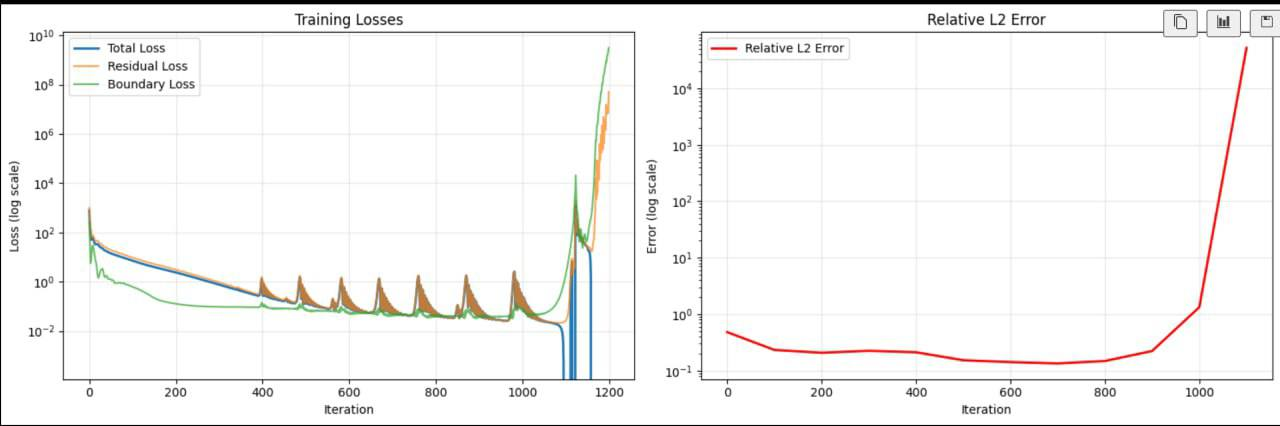

Похоже на взрыв градиента после 1000-й эпохи обучения. В таком случае можно:  
- попробовать примению регулягизацию, если это не было сделано изначально
- если это произошло при регуляшизации, то стоит попробовать поработать с коэффициентом регуляризации
- попробовать использовать другие оптимизаторы - адаптивное изменение размер шага в процессе обучения может помочь